In [1]:
from PIL import Image
import matplotlib.pyplot as plt
import tifffile as tiff
from stl import mesh
import numpy as np

# Open the TIFF image
TIF_FILE = "/Users/amannindra/Projects/llnl_data_science_challenge_2026/data/missing_struts/tif_stacks/210127_Brian_Tran_strut_lattices_0point5dash1 1 Slices.tif"
STL = "/Users/amannindra/Projects/llnl_data_science_challenge_2026/data/missing_struts/stls/0.5.stl"

with tiff.TiffFile(TIF_FILE) as tif:
    # Read the first layer (page) as a NumPy array
    # first_layer = tif.pages[0].asarray()
    first_layer = tif.pages[0].asarray()
    amount = len(tif.pages)
    print(f"type: {tif.pages}")
print(f"Layers: {amount}")


type: <tifffile.TiffPages @8>
Layers: 761


In [2]:
your_mesh = mesh.Mesh.from_file(STL)

mesh_data = your_mesh.data

print(type(mesh_data))

print(len(mesh_data))



<class 'numpy.ndarray'>
3498656


In [3]:
mesh_data[0]

np.void(([-0.026756326, -0.005682311, -0.0061768647], [[-20.743635, -2.4321127, -20.363392], [-20.742199, -2.275659, -20.51354], [-20.70436, -2.454375, -20.513044]], [0]), dtype=[('normals', '<f4', (3,)), ('vectors', '<f4', (3, 3)), ('attr', '<u2', (1,))])

In [4]:
type(first_layer)

numpy.ndarray

In [5]:
first_layer

array([[27998, 28098, 28176, ..., 28656, 29189, 29533],
       [28368, 27970, 28349, ..., 29518, 29770, 29343],
       [28299, 27976, 28280, ..., 28887, 29086, 28572],
       ...,
       [28383, 28562, 27915, ..., 29461, 30102, 30194],
       [28501, 28065, 28060, ..., 29293, 29371, 29457],
       [27802, 28442, 28566, ..., 29995, 29542, 29163]],
      shape=(815, 837), dtype=uint16)

In [6]:
first_layer.shape

(815, 837)

In [7]:
first_layer

array([[27998, 28098, 28176, ..., 28656, 29189, 29533],
       [28368, 27970, 28349, ..., 29518, 29770, 29343],
       [28299, 27976, 28280, ..., 28887, 29086, 28572],
       ...,
       [28383, 28562, 27915, ..., 29461, 30102, 30194],
       [28501, 28065, 28060, ..., 29293, 29371, 29457],
       [27802, 28442, 28566, ..., 29995, 29542, 29163]],
      shape=(815, 837), dtype=uint16)

In [8]:
first_layer

mini = np.where(first_layer > 50000, 1, 0)

mini



array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(815, 837))

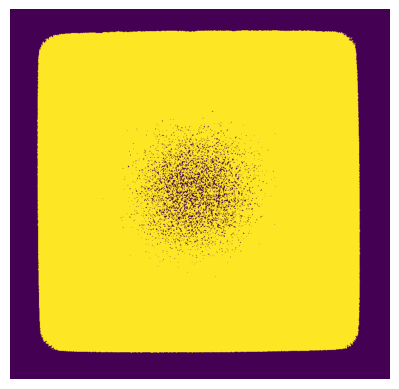

In [9]:
# Display using matplotlib
plt.imshow(mini)
plt.axis('off')  # Hide axis grid lines
plt.show()

In [10]:
  from pathlib import Path
  import sys
  import numpy as np
  import matplotlib.pyplot as plt

  # Make the existing project helpers importable.
  sys.path.insert(0, "/Users/amannindra/Projects/llnl_data_science_challenge_2026/Aman_Scripts")

  from Components.asset_io import read_tiff, inspect_stl
  from Components.coordinates import compose_transforms
  from Components.lattice_graph import load_lattice_graph
  from tif2stl.registration import (
      paired_junction_positions,
      similarity_transform,
      proper_cube_rotations,
      stl_to_design_matrix,
  )
  from tif2stl.validate import build_ct_mask
  from tif2stl.voxelize import voxelize_stl

In [11]:

ROOT = Path("/Users/amannindra/Projects/llnl_data_science_challenge_2026")
DATA = ROOT / "data/missing_struts"

TIFF = DATA / "tif_stacks/210127_Brian_Tran_strut_lattices_0point5dash1 1 Slices.tif"
STL = DATA / "stls/0.5.stl"
DESIGN_JSON = DATA / "octet_truss_9x9x9.json"
REGISTERED_JSON = DATA / "registered_jsons/210127_Brian_Tran_strut_lattices_0point5dash1 1 Slices.json"



In [12]:
downsample = 2
volume = read_tiff(TIFF)
print(type(volume))
print(volume.shape)

ct_mask = build_ct_mask(volume, threshold=40054, downsample=downsample)
del volume

<class 'numpy.memmap'>
(761, 815, 837)


In [ ]:
volume

In [13]:
print(type(ct_mask))
print(ct_mask.shape)

<class 'numpy.ndarray'>
(381, 408, 419)


In [29]:
design = load_lattice_graph(DESIGN_JSON)
print(type(design))
registered = load_lattice_graph(REGISTERED_JSON)
# design_xyz, ct_xyz = paired_junction_positions(design, registered)
# design_to_ct = similarity_transform(design_xyz, ct_xyz).matrix

<class 'Components.lattice_graph.LatticeGraph'>


In [15]:
print(type(registered))

<class 'Components.lattice_graph.LatticeGraph'>


In [16]:
design_xyz, ct_xyz = paired_junction_positions(design, registered)


In [17]:
design_to_ct = similarity_transform(design_xyz, ct_xyz).matrix

In [18]:
type(design_to_ct)

design_to_ct.shape

(4, 4)

In [25]:
stl_info = inspect_stl(STL)
print(type(stl_info))


print(stl_info.bounding_box_max)
print(stl_info.bounding_box_min)

<class 'Components.asset_io.STLMetadata'>
(20.749141693115234, 25.520002365112305, 20.74677276611328)
(-20.743635177612305, -25.520002365112305, -20.74884605407715)


In [20]:
mm_per_design_unit = (
    stl_info.bounding_box_max[0] - stl_info.bounding_box_min[0]
) / 18.0
mm_per_design_unit

2.3051542705959744

In [21]:
stl_center = tuple(
    (low + high) / 2
    for low, high in zip(stl_info.bounding_box_min, stl_info.bounding_box_max)
)
stl_center

(0.0027532577514648438, 0.0, -0.0010366439819335938)

In [22]:
rotation = dict(proper_cube_rotations())["+z+x+y"]
rotation

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [23]:
stl_to_ct = compose_transforms(
    stl_to_design_matrix(
        mm_per_design_unit=mm_per_design_unit,
        stl_center_xyz=stl_center,
        design_center_xyz=(9, 9, 9),
        rotation=rotation,
    ),
    design_to_ct,
)

# 3. STL triangles -> Boolean material voxels on EXACTLY the CT grid.
half_cell = downsample/2
stl_mask = voxelize_stl(
    STL,
    pitch=downsample,
    transform=stl_to_ct,
    origin_xyz=(-half_cell, -half_cell, -half_cell),
    grid_shape_zyx=ct_mask.shape,
    max_grid_voxels=600_000_000
).grid

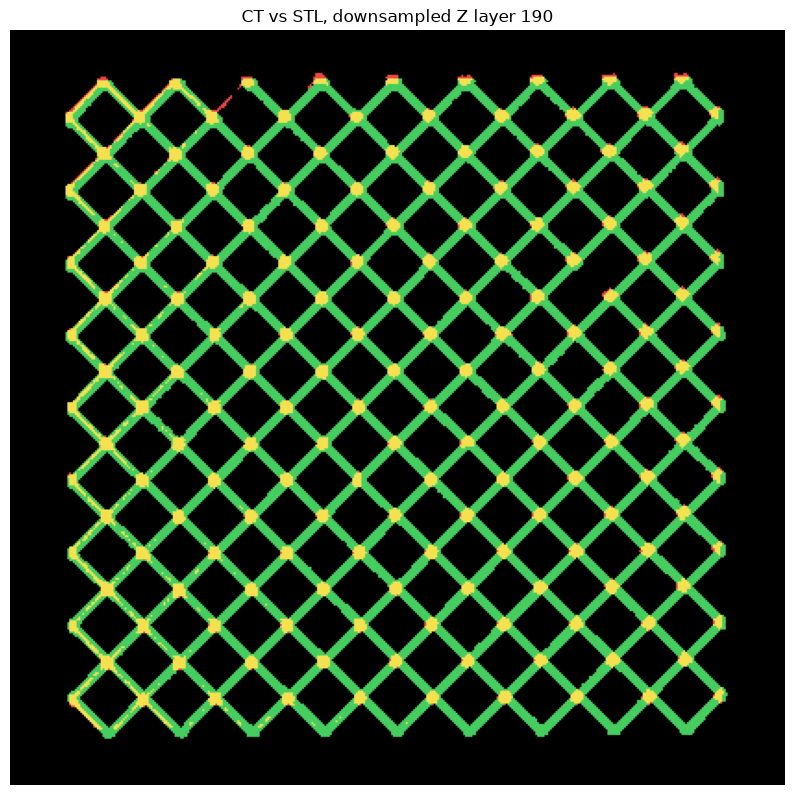

In [24]:
z = ct_mask.shape[0] // 2

ct = ct_mask[z]
stl = stl_mask[z]

# Black = neither
# Red = TIFF says material, STL does not
# Green = STL expects material, TIFF does not
# Yellow = both agree on material
rgb = np.zeros((*ct.shape, 3), dtype=np.uint8)
rgb[ct & ~stl] = (235, 70, 70)
rgb[~ct & stl] = (70, 205, 95)
rgb[ct & stl] = (245, 225, 80)

plt.figure(figsize=(10, 10))
plt.imshow(rgb)
plt.title(f"CT vs STL, downsampled Z layer {z}")
plt.axis("off")
plt.show()    